In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
np.random.seed(42)
movie_lengths = np.random.randint(60, 180, size=200)  # Lengths: 60–180 minutes
labels = np.where((movie_lengths >= 80) & (movie_lengths <= 120), 1, 0)  # 1 = liked, 0 = disliked

# Add 10% noise to simulate real-world imperfection
noise = np.random.rand(200)
labels = np.where(noise < 0.1, 1 - labels, labels)  # Flip 10% of labels

data = pd.DataFrame({'length': movie_lengths, 'liked': labels})

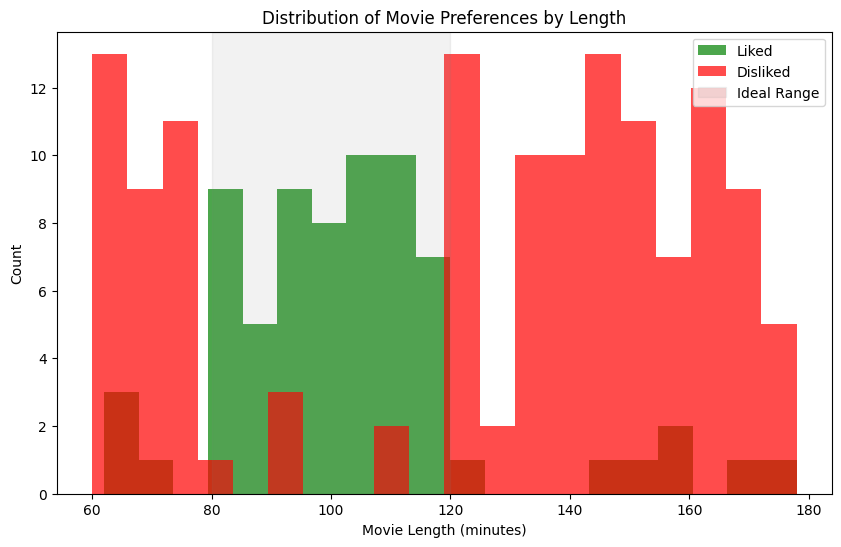

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(data[data['liked'] == 1]['length'], bins=20, alpha=0.7, label='Liked', color='green')
plt.hist(data[data['liked'] == 0]['length'], bins=20, alpha=0.7, label='Disliked', color='red')
plt.axvspan(80, 120, color='gray', alpha=0.1, label='Ideal Range')
plt.title('Distribution of Movie Preferences by Length')
plt.xlabel('Movie Length (minutes)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [4]:
X = data[['length']]
y = data['liked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limit depth for simplicity
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [6]:
y_pred = clf.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.90

Confusion Matrix:
[[28  2]
 [ 2  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.80      0.80      0.80        10

    accuracy                           0.90        40
   macro avg       0.87      0.87      0.87        40
weighted avg       0.90      0.90      0.90        40



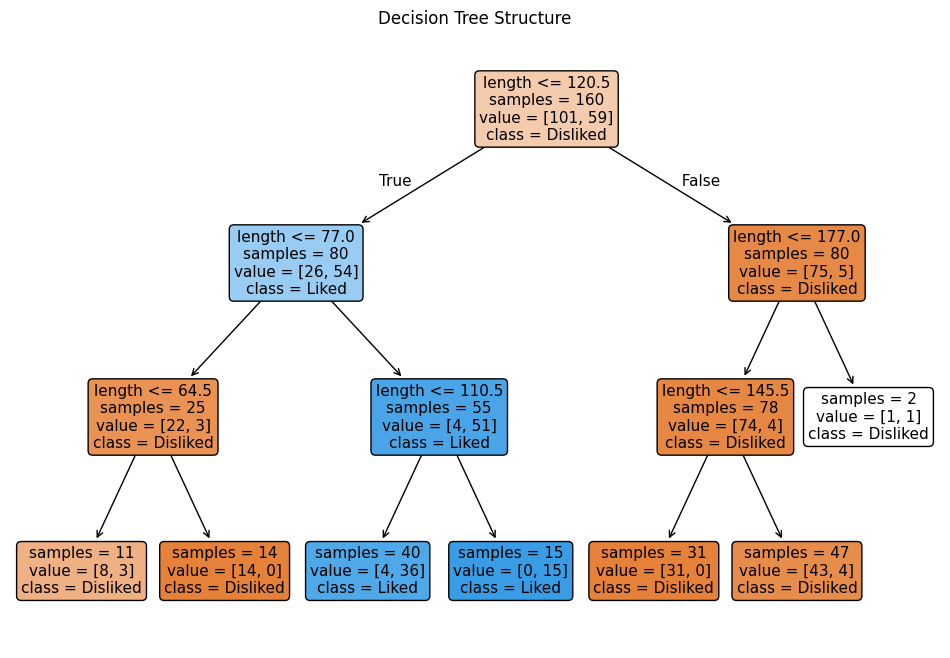

In [7]:
plt.figure(figsize=(12, 8))
plot_tree(clf,
          filled=True,
          feature_names=['length'],
          class_names=['Disliked', 'Liked'],
          rounded=True,
          impurity=False)
plt.title("Decision Tree Structure")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


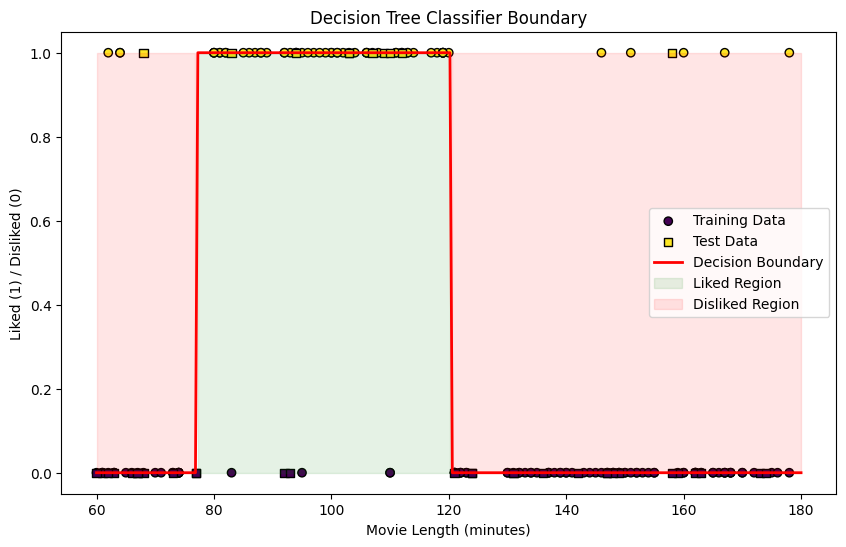

In [8]:
# Create a range of movie lengths
length_range = np.linspace(60, 180, 300).reshape(-1, 1)
predicted_class = clf.predict(length_range)

# Plot decision regions
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c=y_train, cmap='viridis', edgecolor='k', label='Training Data')
plt.scatter(X_test, y_test, c=y_test, cmap='viridis', edgecolor='k', marker='s', label='Test Data')
plt.plot(length_range, predicted_class, color='red', linewidth=2, label='Decision Boundary')
plt.fill_between(length_range.flatten(), 0, 1, where=predicted_class==1, color='green', alpha=0.1, label='Liked Region')
plt.fill_between(length_range.flatten(), 0, 1, where=predicted_class==0, color='red', alpha=0.1, label='Disliked Region')
plt.title('Decision Tree Classifier Boundary')
plt.xlabel('Movie Length (minutes)')
plt.ylabel('Liked (1) / Disliked (0)')
plt.legend()
plt.show()